<a href="https://colab.research.google.com/github/immmma692-boop/DSML-individual/blob/main/3_1_K_means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

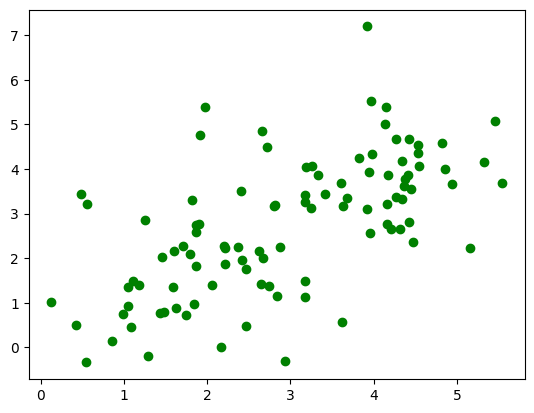

In [ ]:
# import the data generator
from sklearn.datasets import make_blobs

# create a dataset. X is a set of values to cluster; Y is the cluster they belong to
X, y = make_blobs(n_samples=100, n_features=2, centers=2)

# visualise the data in Matplotlib
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], color = 'g')
plt.show()

Phase 1

原始数据形状: (10841, 13)
删除缺失Rating后形状: (9367, 13)
特征矩阵形状: (9367, 12)
训练集大小: (7493, 12), 测试集大小: (1874, 12)

5折交叉验证 R² 分数: [0.17631665 0.12165554 0.10165509 0.1764122  0.14592305]
平均 R²: 0.1444
Fitting 3 folds for each of 30 candidates, totalling 90 fits

最佳参数: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
最佳交叉验证 R²: 0.1525

测试集评估结果:
RMSE: 0.4554
MAE: 0.3173
R²: 0.1590


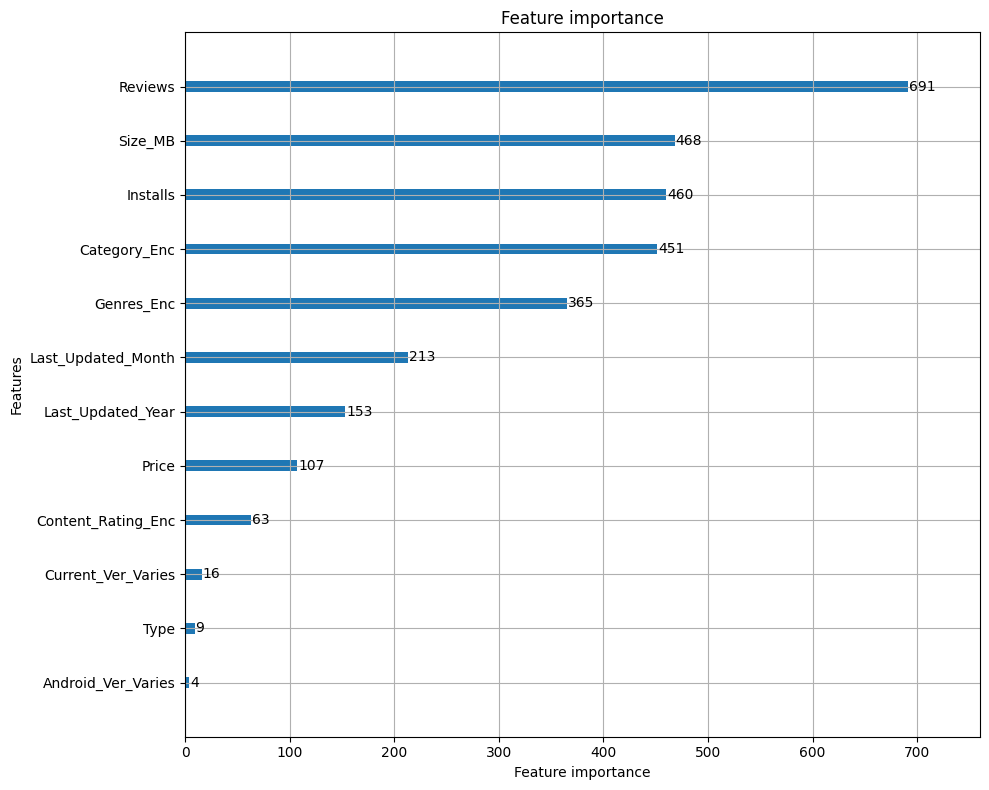

In [12]:
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. 加载数据
# ------------------------------
df = pd.read_excel('/content/DSML Individual Coursework Dataset2526.xlsx', sheet_name='Apps')
print("原始数据形状:", df.shape)

# ------------------------------
# 2. 数据清洗与特征工程
# ------------------------------
# 删除目标变量缺失的行
df = df.dropna(subset=['Rating']).copy()
print("删除缺失Rating后形状:", df.shape)

# 2.1 Reviews: 转为数值
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# 2.2 Size: 转换为MB数值，处理"Varies with device"
def convert_size(size_str):
    if pd.isna(size_str):
        return np.nan
    size_str = str(size_str).strip()
    if size_str == 'Varies with device':
        return np.nan
    match = re.match(r'([\d\.]+)\s*([a-zA-Z]*)', size_str)
    if match:
        num = float(match.group(1))
        unit = match.group(2).upper()
        if unit == 'M':
            return num
        elif unit == 'K':
            return num / 1024.0
        else:
            return np.nan
    return np.nan

df['Size_MB'] = df['Size'].apply(convert_size)

# 2.3 Installs: 去掉逗号和加号，转为整数
def convert_installs(inst_str):
    if pd.isna(inst_str):
        return np.nan
    inst_str = str(inst_str).replace(',', '').replace('+', '').strip()
    try:
        return int(inst_str)
    except:
        return np.nan

df['Installs'] = df['Installs'].apply(convert_installs)

# 2.4 Price: 去掉美元符号，转为浮点数
def convert_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).replace('$', '').replace(',', '').strip()
    try:
        return float(price_str)
    except:
        return np.nan

df['Price'] = df['Price'].apply(convert_price)

# 2.5 Type: 二值化
df['Type'] = df['Type'].map({'Free': 0, 'Paid': 1}).fillna(-1)

# 2.6 Content Rating: 标签编码
le_content = LabelEncoder()
df['Content_Rating_Enc'] = le_content.fit_transform(df['Content Rating'].astype(str))

# 2.7 Category: 标签编码
le_category = LabelEncoder()
df['Category_Enc'] = le_category.fit_transform(df['Category'].astype(str))

# 2.8 Genres: 取第一个类别（若有多值）并进行编码
df['First_Genre'] = df['Genres'].str.split(';').str[0].fillna('Unknown')
le_genre = LabelEncoder()
df['Genres_Enc'] = le_genre.fit_transform(df['First_Genre'])

# 2.9 Last Updated: 提取年份和月份
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df['Last_Updated_Year'] = df['Last Updated'].dt.year.fillna(0).astype(int)
df['Last_Updated_Month'] = df['Last Updated'].dt.month.fillna(0).astype(int)

# 2.10 Current Ver & Android Ver: 是否包含"Varies with device"标志
df['Current_Ver_Varies'] = (df['Current Ver'] == 'Varies with device').astype(int)
df['Android_Ver_Varies'] = (df['Android Ver'] == 'Varies with device').astype(int)

# 2.11 选择特征列
feature_cols = [
    'Reviews', 'Size_MB', 'Installs', 'Price', 'Type',
    'Content_Rating_Enc', 'Category_Enc', 'Genres_Enc',
    'Last_Updated_Year', 'Last_Updated_Month',
    'Current_Ver_Varies', 'Android_Ver_Varies'
]
X = df[feature_cols]
y = df['Rating']

# 2.12 处理数值特征的缺失值（中位数填充）
num_cols = ['Reviews', 'Size_MB', 'Installs', 'Price']
imputer_num = SimpleImputer(strategy='median')
X[num_cols] = imputer_num.fit_transform(X[num_cols])

# 其他特征已用-1或编码填充，无需额外处理
print("特征矩阵形状:", X.shape)

# ------------------------------
# 3. 划分训练集和测试集
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

# ------------------------------
# 4. 基础 LightGBM 模型与交叉验证
# ------------------------------
base_model = lgb.LGBMRegressor(objective='regression', random_state=42,verbosity=-1)
cv_scores = cross_val_score(base_model, X_train, y_train, cv=5, scoring='r2')
print("\n5折交叉验证 R² 分数:", cv_scores)
print("平均 R²: {:.4f}".format(cv_scores.mean()))

# ------------------------------
# 5. 超参数优化（随机搜索）
# ------------------------------
param_dist = {
    'num_leaves': [31, 50, 70, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [-1, 10, 20, 30],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0, 0.01, 0.1]
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,          # 迭代次数，可依据算力调整
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\n最佳参数:", random_search.best_params_)
print("最佳交叉验证 R²: {:.4f}".format(random_search.best_score_))

# ------------------------------
# 6. 最终模型评估
# ------------------------------
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n测试集评估结果:")
print("RMSE: {:.4f}".format(rmse))
print("MAE: {:.4f}".format(mae))
print("R²: {:.4f}".format(r2))

# 可选：特征重要性
lgb.plot_importance(best_model, figsize=(10, 8))
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [ ]:
# min-max scale the X data so it takes values between zero (min value) and one (max value)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X) # transform the data

In [ ]:
# import and fit the clustering algorithm
from sklearn.cluster import KMeans
clustering = KMeans(n_clusters=2).fit(X)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


<Axes: xlabel='x1', ylabel='x2'>

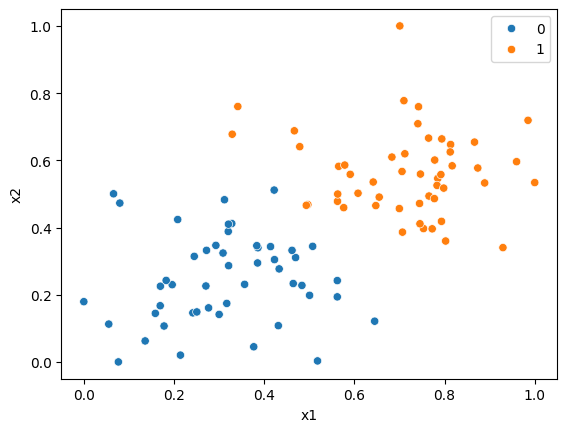

In [ ]:
# add the data and the assigned cluster labels to a Pandas dataframe
import pandas as pd
df = pd.DataFrame(data={'x1': X[:, 0], 'x2': X[:, 1], 'label': clustering.labels_})

# visualise the data using Seaborn
import seaborn as sns
sns.scatterplot(data=df, x='x1', y='x2', hue=df.label.to_list()) # note: we use the “to_list()” function to fix the labels to hue

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


<Axes: xlabel='x1', ylabel='x2'>

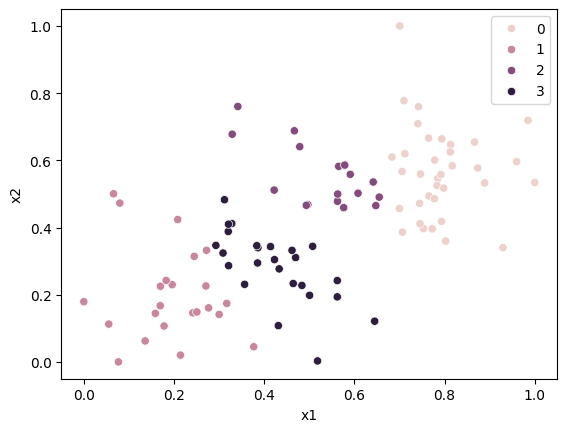

In [ ]:
# fit k-means using k=4
clustering_4 = KMeans(n_clusters=4).fit(X)
df_4 = pd.DataFrame(data={'x1': X[:, 0], 'x2': X[:, 1], 'label': clustering_4.labels_})
sns.scatterplot(data=df_4, x='x1', y='x2', hue=df_4.label.to_list())